# HybridNets Training / Validation Per-Epoch Analysis

This notebook performs a per-epoch data analysis on the metrics produced during training of the HybridNets segmentation head.

Sources:

- `resultJson/train_metrics_history.json`
- `resultJson/val_metrics_history.json`

For every epoch we look at:

1. Losses (total / cls / reg / seg)
2. Segmentation quality (mIoU, mAcc, per-class IoU and accuracy for background / road / lane)
3. Throughput (elapsed seconds, samples / second, number of batches and samples)
4. Optimization state (learning rate before/after scheduler, global step)
5. Confusion matrices (per epoch + final)
6. Train vs. validation gap (to inspect over/under-fitting)

In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda v: f'{v:0.6f}')

RESULT_DIR = Path('resultJson')
TRAIN_PATH = RESULT_DIR / 'train_metrics_history.json'
VAL_PATH   = RESULT_DIR / 'val_metrics_history.json'

CLASS_NAMES = ['background', 'road', 'lane']

## 1. Load raw metrics

In [8]:
with open(TRAIN_PATH) as f:
    train_raw = json.load(f)
with open(VAL_PATH) as f:
    val_raw = json.load(f)

print(f'Train epochs: {len(train_raw)}  (first epoch = {train_raw[0]["epoch"]}, last = {train_raw[-1]["epoch"]})')
print(f'Val   epochs: {len(val_raw)}    (first epoch = {val_raw[0]["epoch"]}, last = {val_raw[-1]["epoch"]})')
print('Keys per epoch entry:')
for k in train_raw[0].keys():
    print(' -', k)

Train epochs: 35  (first epoch = 1, last = 35)
Val   epochs: 35    (first epoch = 1, last = 35)
Keys per epoch entry:
 - loss
 - cls_loss
 - reg_loss
 - seg_loss
 - miou
 - macc
 - class_iou
 - class_acc
 - class_support
 - confusion_matrix
 - num_batches
 - num_samples
 - elapsed_seconds
 - samples_per_second
 - class_iou_by_name
 - class_acc_by_name
 - class_support_by_name
 - epoch
 - global_step
 - lr_before_scheduler
 - lr_after_scheduler


## 2. Flatten each epoch into a tidy DataFrame

`class_iou_by_name`, `class_acc_by_name` and `class_support_by_name` are expanded into per-class columns. `confusion_matrix` is kept aside as a list of 2-D arrays for later inspection.

In [9]:
def flatten_history(history, split_name):
    rows = []
    cms = []
    for entry in history:
        row = {
            'split':              split_name,
            'epoch':              entry['epoch'],
            'global_step':        entry['global_step'],
            'loss':               entry['loss'],
            'cls_loss':           entry['cls_loss'],
            'reg_loss':           entry['reg_loss'],
            'seg_loss':           entry['seg_loss'],
            'miou':               entry['miou'],
            'macc':               entry['macc'],
            'num_batches':        entry['num_batches'],
            'num_samples':        entry['num_samples'],
            'elapsed_seconds':    entry['elapsed_seconds'],
            'samples_per_second': entry['samples_per_second'],
            'lr_before_scheduler': entry['lr_before_scheduler'],
            'lr_after_scheduler':  entry['lr_after_scheduler'],
        }
        for cname in CLASS_NAMES:
            row[f'iou_{cname}']     = entry['class_iou_by_name'][cname]
            row[f'acc_{cname}']     = entry['class_acc_by_name'][cname]
            row[f'support_{cname}'] = entry['class_support_by_name'][cname]
        rows.append(row)
        cms.append(np.array(entry['confusion_matrix'], dtype=np.int64))
    df = pd.DataFrame(rows).sort_values('epoch').reset_index(drop=True)
    return df, cms

train_df, train_cms = flatten_history(train_raw, 'train')
val_df,   val_cms   = flatten_history(val_raw,   'val')

print('train_df shape:', train_df.shape)
print('val_df   shape:', val_df.shape)
train_df.head()

train_df shape: (35, 24)
val_df   shape: (35, 24)


,split,epoch,global_step,loss,cls_loss,reg_loss,seg_loss,miou,macc,num_batches,num_samples,elapsed_seconds,samples_per_second,lr_before_scheduler,lr_after_scheduler,iou_background,acc_background,support_background,iou_road,acc_road,support_road,iou_lane,acc_lane,support_lane
0,train,1,5834,0.233620,0.000000,0.000000,0.233620,0.641787,0.731596,5834,70000,1610.865304,43.454906,0.001000,0.001000,0.930422,0.966254,14062111630,0.709406,0.830037,2814522272,0.285534,0.398497,326566098
1,train,2,11668,0.154141,0.000000,0.000000,0.154141,0.721690,0.796830,5834,70000,1581.429256,44.263757,0.001000,0.001000,0.955194,0.979507,14062548671,0.801878,0.889331,2814172190,0.407999,0.521654,326479139
2,train,3,17502,0.137648,0.000000,0.000000,0.137648,0.740682,0.813043,5834,70000,1575.372114,44.433946,0.001000,0.001000,0.959927,0.981714,14062149668,0.821895,0.901851,2814512571,0.440224,0.555565,326537761
3,train,4,23336,0.129034,0.000000,0.000000,0.129034,0.751072,0.821861,5834,70000,1575.837015,44.420838,0.001000,0.001000,0.962394,0.982827,14062474414,0.832522,0.908495,2814292484,0.458300,0.574260,326433102
4,train,5,29170,0.124021,0.000000,0.000000,0.124021,0.757236,0.826883,5834,70000,1586.940294,44.110040,0.001000,0.001000,0.963873,0.983591,14062702405,0.838945,0.912049,2813961572,0.468891,0.585009,326536023


In [10]:
val_df.head()

,split,epoch,global_step,loss,cls_loss,reg_loss,seg_loss,miou,macc,num_batches,num_samples,elapsed_seconds,samples_per_second,lr_before_scheduler,lr_after_scheduler,iou_background,acc_background,support_background,iou_road,acc_road,support_road,iou_lane,acc_lane,support_lane
0,val,1,5834,0.248693,0.000000,0.000000,0.248693,0.640553,0.794122,834,10000,119.743463,83.511866,0.001000,0.001000,0.950974,0.975653,2028541202,0.782904,0.850841,414164020,0.187781,0.555871,14894778
1,val,2,11668,0.233400,0.000000,0.000000,0.233400,0.654952,0.814384,834,10000,121.712589,82.160770,0.001000,0.001000,0.954984,0.977061,2028541202,0.802579,0.866167,414164020,0.207292,0.599923,14894778
2,val,3,17502,0.219303,0.000000,0.000000,0.219303,0.670822,0.830254,834,10000,118.929832,84.083193,0.001000,0.001000,0.961403,0.975702,2028541202,0.832217,0.906717,414164020,0.218847,0.608342,14894778
3,val,4,23336,0.224607,0.000000,0.000000,0.224607,0.663333,0.840134,834,10000,117.312106,85.242695,0.001000,0.001000,0.959142,0.980792,2028541202,0.816347,0.861779,414164020,0.214510,0.677832,14894778
4,val,5,29170,0.218909,0.000000,0.000000,0.218909,0.670737,0.838643,834,10000,117.938390,84.790033,0.001000,0.001000,0.961346,0.978053,2028541202,0.828188,0.890862,414164020,0.222678,0.647012,14894778


## 3. Per-epoch summary tables

A compact view of every epoch: losses, mIoU, mAcc, per-class IoU/accuracy, throughput and learning rate.

In [11]:
summary_cols = [
    'epoch', 'loss', 'seg_loss', 'miou', 'macc',
    'iou_background', 'iou_road', 'iou_lane',
    'acc_background', 'acc_road', 'acc_lane',
    'elapsed_seconds', 'samples_per_second',
    'lr_before_scheduler', 'lr_after_scheduler',
]

print('=== TRAIN per-epoch summary ===')
train_df[summary_cols]

=== TRAIN per-epoch summary ===


,epoch,loss,seg_loss,miou,macc,iou_background,iou_road,iou_lane,acc_background,acc_road,acc_lane,elapsed_seconds,samples_per_second,lr_before_scheduler,lr_after_scheduler
0,1,0.233620,0.233620,0.641787,0.731596,0.930422,0.709406,0.285534,0.966254,0.830037,0.398497,1610.865304,43.454906,0.001000,0.001000
1,2,0.154141,0.154141,0.721690,0.796830,0.955194,0.801878,0.407999,0.979507,0.889331,0.521654,1581.429256,44.263757,0.001000,0.001000
2,3,0.137648,0.137648,0.740682,0.813043,0.959927,0.821895,0.440224,0.981714,0.901851,0.555565,1575.372114,44.433946,0.001000,0.001000
3,4,0.129034,0.129034,0.751072,0.821861,0.962394,0.832522,0.458300,0.982827,0.908495,0.574260,1575.837015,44.420838,0.001000,0.001000
4,5,0.124021,0.124021,0.757236,0.826883,0.963873,0.838945,0.468891,0.983591,0.912049,0.585009,1586.940294,44.110040,0.001000,0.001000
5,6,0.120087,0.120087,0.762126,0.830837,0.965050,0.844004,0.477324,0.984206,0.914787,0.593518,1575.694514,44.424855,0.001000,0.001000
6,7,0.117294,0.117294,0.765558,0.833548,0.965898,0.847645,0.483132,0.984676,0.916625,0.599342,1574.329475,44.463374,0.001000,0.001000
7,8,0.115041,0.115041,0.768378,0.835946,0.966530,0.850421,0.488182,0.984972,0.918220,0.604645,1562.484549,44.800443,0.001000,0.001000
8,9,0.113101,0.113101,0.770902,0.837853,0.967177,0.853311,0.492218,0.985316,0.919791,0.608453,1575.456831,44.431557,0.001000,0.001000
9,10,0.111836,0.111836,0.772694,0.839392,0.967542,0.854843,0.495698,0.985487,0.920651,0.612040,1585.434134,44.151945,0.001000,0.001000


In [12]:
print('=== VAL per-epoch summary ===')
val_df[summary_cols]

=== VAL per-epoch summary ===


,epoch,loss,seg_loss,miou,macc,iou_background,iou_road,iou_lane,acc_background,acc_road,acc_lane,elapsed_seconds,samples_per_second,lr_before_scheduler,lr_after_scheduler
0,1,0.248693,0.248693,0.640553,0.794122,0.950974,0.782904,0.187781,0.975653,0.850841,0.555871,119.743463,83.511866,0.001000,0.001000
1,2,0.233400,0.233400,0.654952,0.814384,0.954984,0.802579,0.207292,0.977061,0.866167,0.599923,121.712589,82.160770,0.001000,0.001000
2,3,0.219303,0.219303,0.670822,0.830254,0.961403,0.832217,0.218847,0.975702,0.906717,0.608342,118.929832,84.083193,0.001000,0.001000
3,4,0.224607,0.224607,0.663333,0.840134,0.959142,0.816347,0.214510,0.980792,0.861779,0.677832,117.312106,85.242695,0.001000,0.001000
4,5,0.218909,0.218909,0.670737,0.838643,0.961346,0.828188,0.222678,0.978053,0.890862,0.647012,117.938390,84.790033,0.001000,0.001000
5,6,0.212979,0.212979,0.677267,0.852927,0.963626,0.840682,0.227493,0.978611,0.898986,0.681183,118.724490,84.228620,0.001000,0.001000
6,7,0.213508,0.213508,0.677431,0.854414,0.963462,0.841251,0.227579,0.978852,0.897331,0.687059,121.529242,82.284723,0.001000,0.001000
7,8,0.215570,0.215570,0.677120,0.861748,0.964934,0.844227,0.222200,0.977990,0.903772,0.703481,120.511348,82.979738,0.001000,0.001000
8,9,0.210997,0.210997,0.680595,0.859060,0.964753,0.846668,0.230365,0.979149,0.901958,0.696073,122.398205,81.700544,0.001000,0.001000
9,10,0.210674,0.210674,0.679255,0.855329,0.964926,0.843223,0.229617,0.981421,0.889976,0.694589,120.833584,82.758449,0.001000,0.001000


## 4. Descriptive statistics across epochs

In [13]:
metric_cols = ['loss', 'seg_loss', 'miou', 'macc',
               'iou_background', 'iou_road', 'iou_lane',
               'acc_background', 'acc_road', 'acc_lane',
               'elapsed_seconds', 'samples_per_second']

stats = pd.concat({
    'train': train_df[metric_cols].describe().T,
    'val':   val_df[metric_cols].describe().T,
}, axis=1)
stats

train                                                                                         val                                                                           
                       count        mean       std         min         25%         50%         75%         max     count       mean      std        min        25%        50%        75%        max
loss               35.000000    0.109336  0.026420    0.087446    0.091300    0.105502    0.112468    0.233620 35.000000   0.208735 0.010735   0.199120   0.200026   0.207006   0.211680   0.248693
seg_loss           35.000000    0.109336  0.026420    0.087446    0.091300    0.105502    0.112468    0.233620 35.000000   0.208735 0.010735   0.199120   0.200026   0.207006   0.211680   0.248693
miou               35.000000    0.777330  0.030752    0.641787    0.771798    0.780843    0.800459    0.806034 35.000000   0.681958 0.011468   0.640553   0.677349   0.682276   0.691426   0.692728
macc               35.000000    0.842580  0.024875    0.731596    0.838623    0.845836    0.860879    0.864963 35.000000   0.859582 0.018764   0.794122   0.854871   0.862596   0.874642   0.878462
iou_background     35.000000    0.968621  0.008262    0.930422    0.967359    0.969442    0.974550    0.976109 35.000000   0.965110 0.003948   0.950974   0.964189   0.965477   0.968395   0.968876
iou_road           35.000000    0.860497  0.034114    0.709406    0.854077    0.863321    0.886399    0.893543 35.000000   0.846932 0.018249   0.782904   0.842237   0.848469   0.861955   0.864027
iou_lane           35.000000    0.502871  0.049938    0.285534    0.493958    0.509768    0.540430    0.548448 35.000000   0.233833 0.012609   0.187781   0.229991   0.235469   0.243910   0.245513
acc_background     35.000000    0.986025  0.004205    0.966254    0.985401    0.986492    0.988955    0.989698 35.000000   0.979797 0.001954   0.975653   0.978460   0.980359   0.981284   0.983552
acc_road           35.000000    0.923314  0.020362    0.830037    0.920221    0.925056    0.938180    0.942276 35.000000   0.900435 0.016567   0.850841   0.896870   0.906236   0.910945   0.919304
acc_lane           35.000000    0.618400  0.050131    0.398497    0.610247    0.625960    0.655503    0.662920 35.000000   0.698515 0.042942   0.555871   0.683258   0.703481   0.733382   0.741961
elapsed_seconds    35.000000 1570.154266 22.337298 1505.693355 1574.190533 1575.837015 1578.935773 1610.865304 35.000000 119.770119 1.418576 116.628080 118.913848 119.709199 120.672466 122.398205
samples_per_second 35.000000   44.590608  0.651416   43.454906   44.333659   44.420838   44.467299   46.490210 35.000000  83.504669 0.989966  81.700544  82.869093  83.535769  84.094496  85.742645

## 5. Best / worst epochs per metric

For each key metric we pick the epoch achieving the best value, for both train and val.
Loss is minimized, everything else is maximized.

In [14]:
def best_epoch_table(df, split_name):
    rules = {
        'loss':            'min',
        'seg_loss':        'min',
        'miou':            'max',
        'macc':            'max',
        'iou_background':  'max',
        'iou_road':        'max',
        'iou_lane':        'max',
        'acc_background':  'max',
        'acc_road':        'max',
        'acc_lane':        'max',
    }
    rows = []
    for metric, how in rules.items():
        if how == 'min':
            idx = df[metric].idxmin()
        else:
            idx = df[metric].idxmax()
        rows.append({
            'split':    split_name,
            'metric':   metric,
            'best_epoch': int(df.loc[idx, 'epoch']),
            'value':    df.loc[idx, metric],
            'direction': how,
        })
    return pd.DataFrame(rows)

best_df = pd.concat([best_epoch_table(train_df, 'train'),
                     best_epoch_table(val_df,   'val')], ignore_index=True)
best_df

,split,metric,best_epoch,value,direction
0,train,loss,34,0.087446,min
1,train,seg_loss,34,0.087446,min
2,train,miou,34,0.806034,max
3,train,macc,34,0.864963,max
4,train,iou_background,34,0.976109,max
5,train,iou_road,34,0.893543,max
6,train,iou_lane,34,0.548448,max
7,train,acc_background,34,0.989698,max
8,train,acc_road,35,0.942276,max
9,train,acc_lane,34,0.662920,max


## 6. Epoch-over-epoch deltas

How much each metric changed from one epoch to the next - useful to see where the model actually learns vs. plateaus.

In [15]:
def deltas(df):
    out = df[['epoch']].copy()
    for col in ['loss', 'seg_loss', 'miou', 'macc',
                'iou_background', 'iou_road', 'iou_lane']:
        out[f'd_{col}'] = df[col].diff()
    return out

print('=== TRAIN deltas ===')
display(deltas(train_df))
print('=== VAL deltas ===')
display(deltas(val_df))

=== TRAIN deltas ===


,epoch,d_loss,d_seg_loss,d_miou,d_macc,d_iou_background,d_iou_road,d_iou_lane
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,-0.079479,-0.079479,0.079903,0.065235,0.024773,0.092472,0.122465
2,3,-0.016493,-0.016493,0.018991,0.016213,0.004733,0.020017,0.032225
3,4,-0.008614,-0.008614,0.010390,0.008818,0.002467,0.010627,0.018076
4,5,-0.005012,-0.005012,0.006164,0.005022,0.001479,0.006423,0.010591
5,6,-0.003934,-0.003934,0.004890,0.003954,0.001177,0.005059,0.008433
6,7,-0.002793,-0.002793,0.003432,0.002711,0.000848,0.003641,0.005808
7,8,-0.002254,-0.002254,0.002820,0.002398,0.000633,0.002776,0.005050
8,9,-0.001940,-0.001940,0.002524,0.001907,0.000646,0.002891,0.004036
9,10,-0.001265,-0.001265,0.001792,0.001539,0.000365,0.001531,0.003480


=== VAL deltas ===


,epoch,d_loss,d_seg_loss,d_miou,d_macc,d_iou_background,d_iou_road,d_iou_lane
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,-0.015293,-0.015293,0.014399,0.020262,0.004010,0.019674,0.019512
2,3,-0.014097,-0.014097,0.015870,0.015870,0.006418,0.029638,0.011555
3,4,0.005303,0.005303,-0.007489,0.009880,-0.002261,-0.015870,-0.004337
4,5,-0.005697,-0.005697,0.007404,-0.001492,0.002204,0.011841,0.008168
5,6,-0.005930,-0.005930,0.006530,0.014284,0.002281,0.012494,0.004815
6,7,0.000528,0.000528,0.000164,0.001487,-0.000164,0.000569,0.000087
7,8,0.002063,0.002063,-0.000310,0.007334,0.001472,0.002977,-0.005379
8,9,-0.004573,-0.004573,0.003475,-0.002688,-0.000181,0.002441,0.008166
9,10,-0.000324,-0.000324,-0.001340,-0.003731,0.000173,-0.003445,-0.000748


## 7. Train vs Validation gap (overfitting check)

Positive `train - val` on IoU / accuracy means training is better than validation (the usual case);
growing gap over epochs is a classic overfitting signal.

In [16]:
gap_cols = ['loss', 'seg_loss', 'miou', 'macc',
            'iou_background', 'iou_road', 'iou_lane',
            'acc_background', 'acc_road', 'acc_lane']

gap_df = pd.DataFrame({'epoch': train_df['epoch']})
for col in gap_cols:
    gap_df[f'train_{col}'] = train_df[col].values
    gap_df[f'val_{col}']   = val_df[col].values
    gap_df[f'gap_{col}']   = train_df[col].values - val_df[col].values
gap_df

,epoch,train_loss,val_loss,gap_loss,train_seg_loss,val_seg_loss,gap_seg_loss,train_miou,val_miou,gap_miou,train_macc,val_macc,gap_macc,train_iou_background,val_iou_background,gap_iou_background,train_iou_road,val_iou_road,gap_iou_road,train_iou_lane,val_iou_lane,gap_iou_lane,train_acc_background,val_acc_background,gap_acc_background,train_acc_road,val_acc_road,gap_acc_road,train_acc_lane,val_acc_lane,gap_acc_lane
0,1,0.233620,0.248693,-0.015073,0.233620,0.248693,-0.015073,0.641787,0.640553,0.001234,0.731596,0.794122,-0.062526,0.930422,0.950974,-0.020553,0.709406,0.782904,-0.073499,0.285534,0.187781,0.097753,0.966254,0.975653,-0.009400,0.830037,0.850841,-0.020804,0.398497,0.555871,-0.157373
1,2,0.154141,0.233400,-0.079260,0.154141,0.233400,-0.079260,0.721690,0.654952,0.066739,0.796830,0.814384,-0.017553,0.955194,0.954984,0.000210,0.801878,0.802579,-0.000701,0.407999,0.207292,0.200706,0.979507,0.977061,0.002446,0.889331,0.866167,0.023163,0.521654,0.599923,-0.078269
2,3,0.137648,0.219303,-0.081655,0.137648,0.219303,-0.081655,0.740682,0.670822,0.069860,0.813043,0.830254,-0.017211,0.959927,0.961403,-0.001475,0.821895,0.832217,-0.010322,0.440224,0.218847,0.221377,0.981714,0.975702,0.006011,0.901851,0.906717,-0.004866,0.555565,0.608342,-0.052778
3,4,0.129034,0.224607,-0.095573,0.129034,0.224607,-0.095573,0.751072,0.663333,0.087739,0.821861,0.840134,-0.018273,0.962394,0.959142,0.003253,0.832522,0.816347,0.016175,0.458300,0.214510,0.243790,0.982827,0.980792,0.002036,0.908495,0.861779,0.046716,0.574260,0.677832,-0.103572
4,5,0.124021,0.218909,-0.094888,0.124021,0.218909,-0.094888,0.757236,0.670737,0.086499,0.826883,0.838643,-0.011760,0.963873,0.961346,0.002527,0.838945,0.828188,0.010757,0.468891,0.222678,0.246213,0.983591,0.978053,0.005539,0.912049,0.890862,0.021187,0.585009,0.647012,-0.062003
5,6,0.120087,0.212979,-0.092892,0.120087,0.212979,-0.092892,0.762126,0.677267,0.084859,0.830837,0.852927,-0.022090,0.965050,0.963626,0.001424,0.844004,0.840682,0.003322,0.477324,0.227493,0.249832,0.984206,0.978611,0.005595,0.914787,0.898986,0.015800,0.593518,0.681183,-0.087665
6,7,0.117294,0.213508,-0.096213,0.117294,0.213508,-0.096213,0.765558,0.677431,0.088127,0.833548,0.854414,-0.020866,0.965898,0.963462,0.002436,0.847645,0.841251,0.006394,0.483132,0.227579,0.255553,0.984676,0.978852,0.005824,0.916625,0.897331,0.019295,0.599342,0.687059,-0.087716
7,8,0.115041,0.215570,-0.100530,0.115041,0.215570,-0.100530,0.768378,0.677120,0.091257,0.835946,0.861748,-0.025802,0.966530,0.964934,0.001596,0.850421,0.844227,0.006193,0.488182,0.222200,0.265982,0.984972,0.977990,0.006983,0.918220,0.903772,0.014449,0.604645,0.703481,-0.098837
8,9,0.113101,0.210997,-0.097897,0.113101,0.210997,-0.097897,0.770902,0.680595,0.090307,0.837853,0.859060,-0.021207,0.967177,0.964753,0.002424,0.853311,0.846668,0.006643,0.492218,0.230365,0.261853,0.985316,0.979149,0.006166,0.919791,0.901958,0.017833,0.608453,0.696073,-0.087619
9,10,0.111836,0.210674,-0.098837,0.111836,0.210674,-0.098837,0.772694,0.679255,0.093439,0.839392,0.855329,-0.015936,0.967542,0.964926,0.002617,0.854843,0.843223,0.011620,0.495698,0.229617,0.266081,0.985487,0.981421,0.004065,0.920651,0.889976,0.030674,0.612040,0.694589,-0.082549


## 8. Visualisations

### 8.1 Loss curves

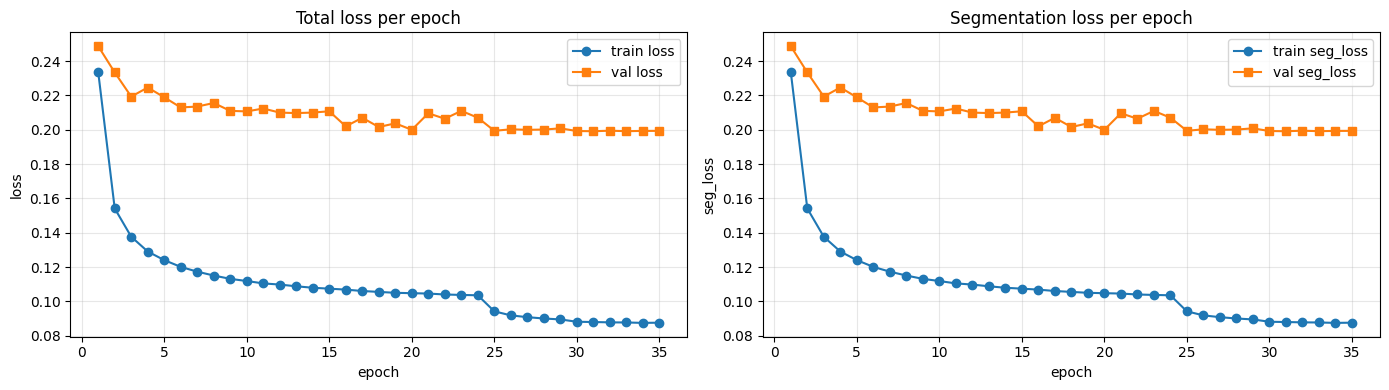

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_df['epoch'], train_df['loss'],    marker='o', label='train loss')
axes[0].plot(val_df['epoch'],   val_df['loss'],      marker='s', label='val loss')
axes[0].set_title('Total loss per epoch')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(train_df['epoch'], train_df['seg_loss'], marker='o', label='train seg_loss')
axes[1].plot(val_df['epoch'],   val_df['seg_loss'],   marker='s', label='val seg_loss')
axes[1].set_title('Segmentation loss per epoch')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('seg_loss'); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

### 8.2 mIoU and mAcc

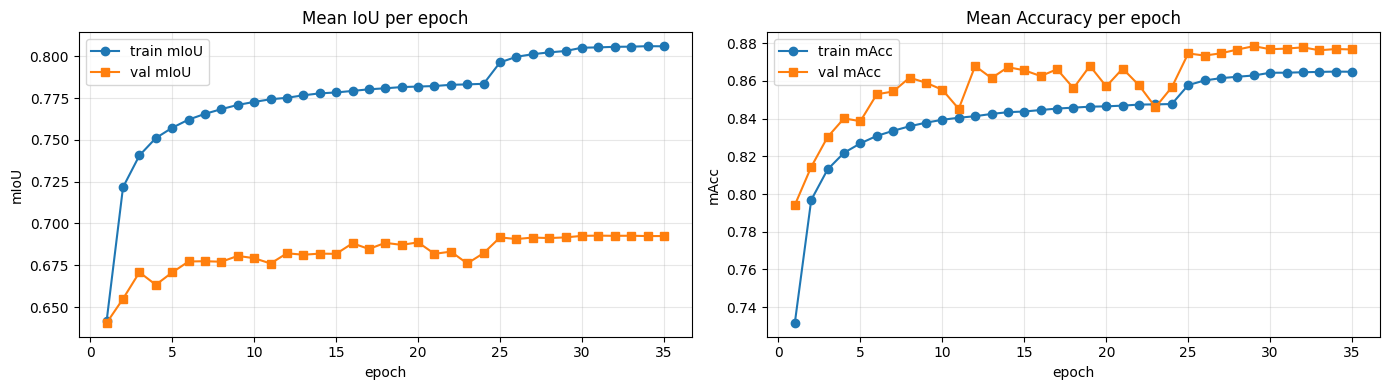

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_df['epoch'], train_df['miou'], marker='o', label='train mIoU')
axes[0].plot(val_df['epoch'],   val_df['miou'],   marker='s', label='val mIoU')
axes[0].set_title('Mean IoU per epoch')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('mIoU'); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(train_df['epoch'], train_df['macc'], marker='o', label='train mAcc')
axes[1].plot(val_df['epoch'],   val_df['macc'],   marker='s', label='val mAcc')
axes[1].set_title('Mean Accuracy per epoch')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('mAcc'); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

### 8.3 Per-class IoU and accuracy

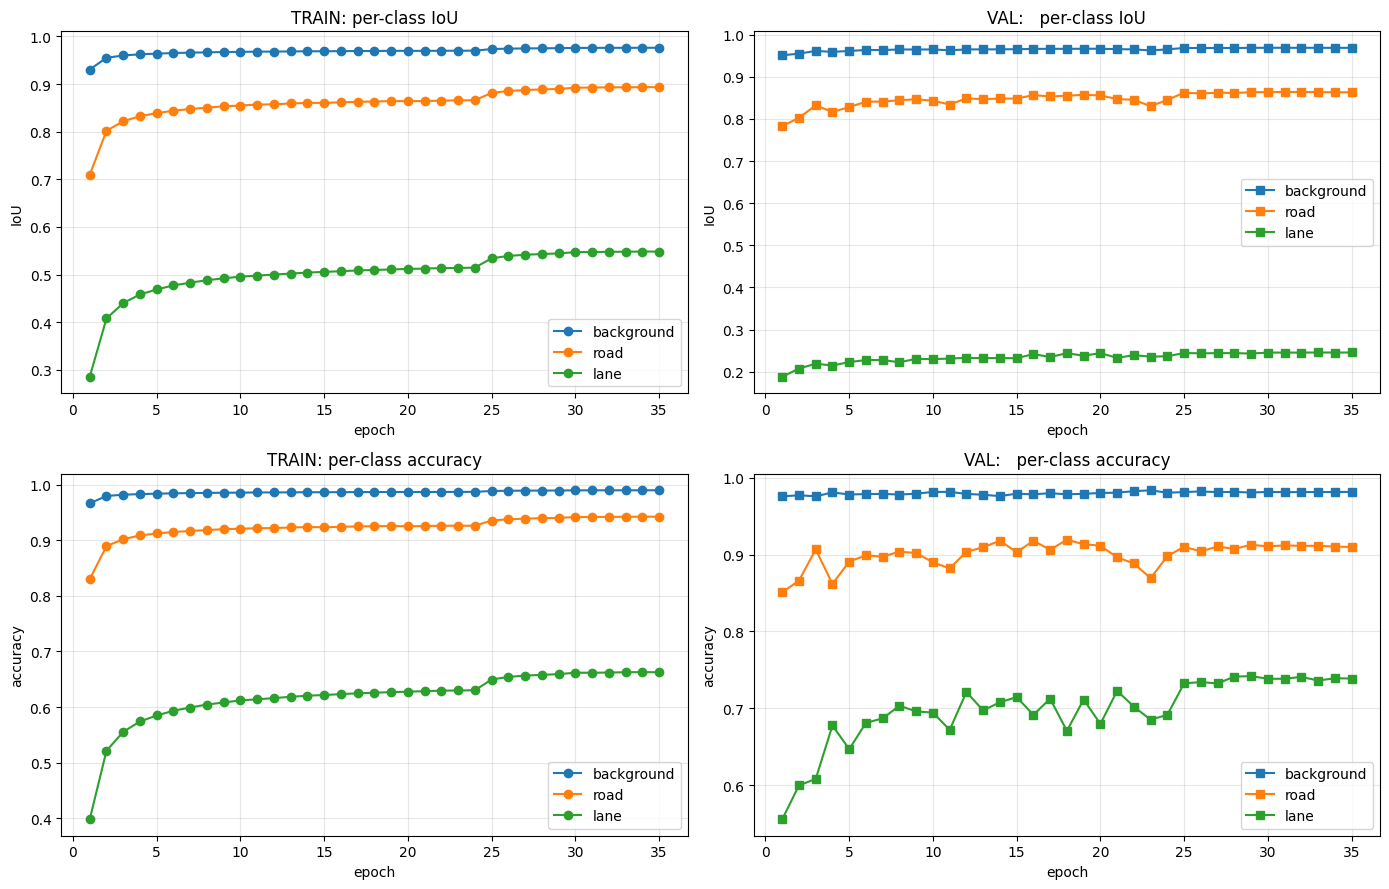

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for cname in CLASS_NAMES:
    axes[0, 0].plot(train_df['epoch'], train_df[f'iou_{cname}'], marker='o', label=cname)
    axes[0, 1].plot(val_df['epoch'],   val_df[f'iou_{cname}'],   marker='s', label=cname)
    axes[1, 0].plot(train_df['epoch'], train_df[f'acc_{cname}'], marker='o', label=cname)
    axes[1, 1].plot(val_df['epoch'],   val_df[f'acc_{cname}'],   marker='s', label=cname)

axes[0, 0].set_title('TRAIN: per-class IoU');    axes[0, 0].set_xlabel('epoch'); axes[0, 0].set_ylabel('IoU')
axes[0, 1].set_title('VAL:   per-class IoU');    axes[0, 1].set_xlabel('epoch'); axes[0, 1].set_ylabel('IoU')
axes[1, 0].set_title('TRAIN: per-class accuracy');axes[1, 0].set_xlabel('epoch'); axes[1, 0].set_ylabel('accuracy')
axes[1, 1].set_title('VAL:   per-class accuracy');axes[1, 1].set_xlabel('epoch'); axes[1, 1].set_ylabel('accuracy')

for ax in axes.ravel():
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout(); plt.show()

### 8.4 Learning rate schedule

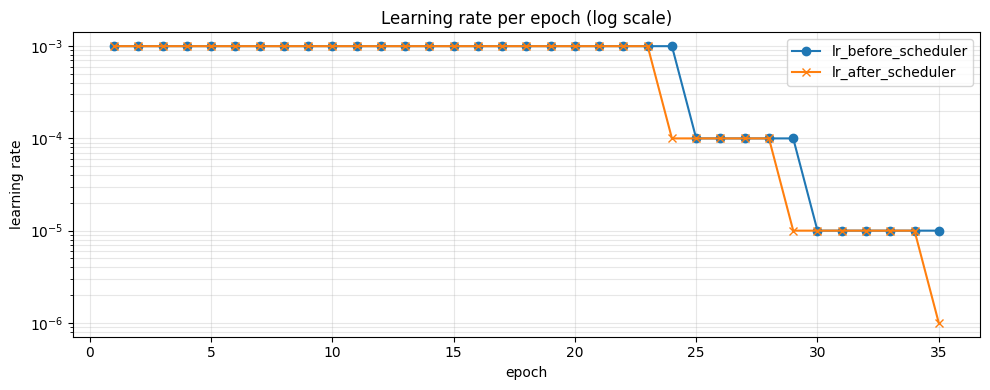

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_df['epoch'], train_df['lr_before_scheduler'], marker='o', label='lr_before_scheduler')
ax.plot(train_df['epoch'], train_df['lr_after_scheduler'],  marker='x', label='lr_after_scheduler')
ax.set_yscale('log')
ax.set_title('Learning rate per epoch (log scale)')
ax.set_xlabel('epoch'); ax.set_ylabel('learning rate')
ax.grid(True, which='both', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

### 8.5 Throughput: elapsed seconds and samples/second

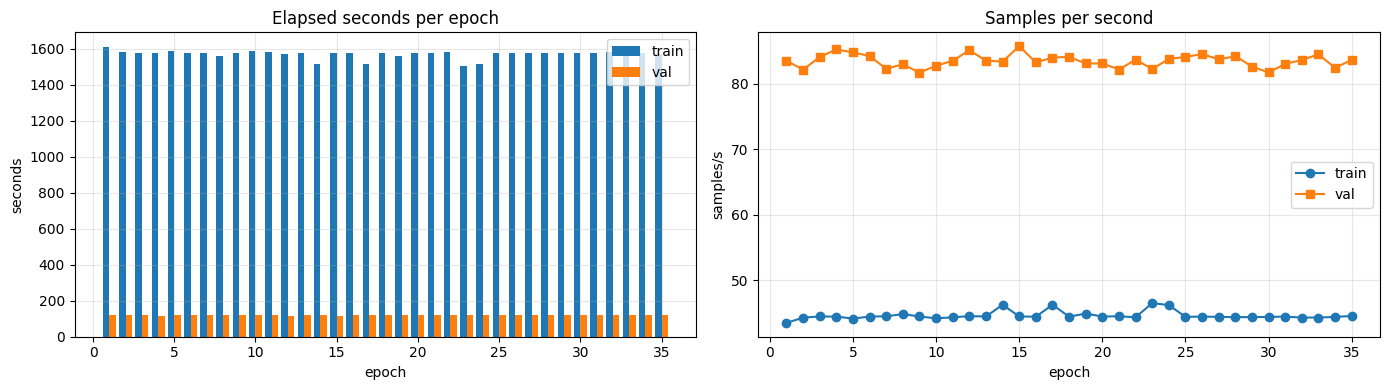

Total training time across 35 epochs: 915.92 min
Total validation time across 35 epochs: 69.87 min


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(train_df['epoch'] - 0.2, train_df['elapsed_seconds'], width=0.4, label='train')
axes[0].bar(val_df['epoch']   + 0.2, val_df['elapsed_seconds'],   width=0.4, label='val')
axes[0].set_title('Elapsed seconds per epoch')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('seconds'); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(train_df['epoch'], train_df['samples_per_second'], marker='o', label='train')
axes[1].plot(val_df['epoch'],   val_df['samples_per_second'],   marker='s', label='val')
axes[1].set_title('Samples per second')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('samples/s'); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

total_train_minutes = train_df['elapsed_seconds'].sum() / 60.0
total_val_minutes   = val_df['elapsed_seconds'].sum()   / 60.0
print(f'Total training time across {len(train_df)} epochs: {total_train_minutes:0.2f} min')
print(f'Total validation time across {len(val_df)} epochs: {total_val_minutes:0.2f} min')

### 8.6 Train - Val gap

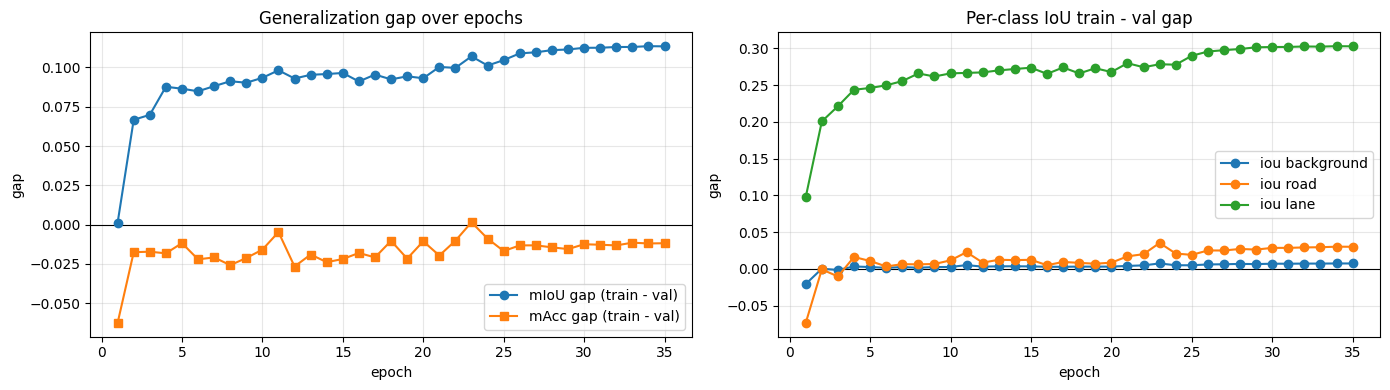

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].axhline(0, color='k', linewidth=0.8)
axes[0].plot(gap_df['epoch'], gap_df['gap_miou'], marker='o', label='mIoU gap (train - val)')
axes[0].plot(gap_df['epoch'], gap_df['gap_macc'], marker='s', label='mAcc gap (train - val)')
axes[0].set_title('Generalization gap over epochs')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('gap'); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].axhline(0, color='k', linewidth=0.8)
for cname in CLASS_NAMES:
    axes[1].plot(gap_df['epoch'], gap_df[f'gap_iou_{cname}'], marker='o', label=f'iou {cname}')
axes[1].set_title('Per-class IoU train - val gap')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('gap'); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()

## 9. Confusion matrix analysis

Each confusion matrix is 3x3 (`background`, `road`, `lane`). Rows are the ground-truth class, columns are the predicted class. We look at the row-normalized (recall) version for interpretability.

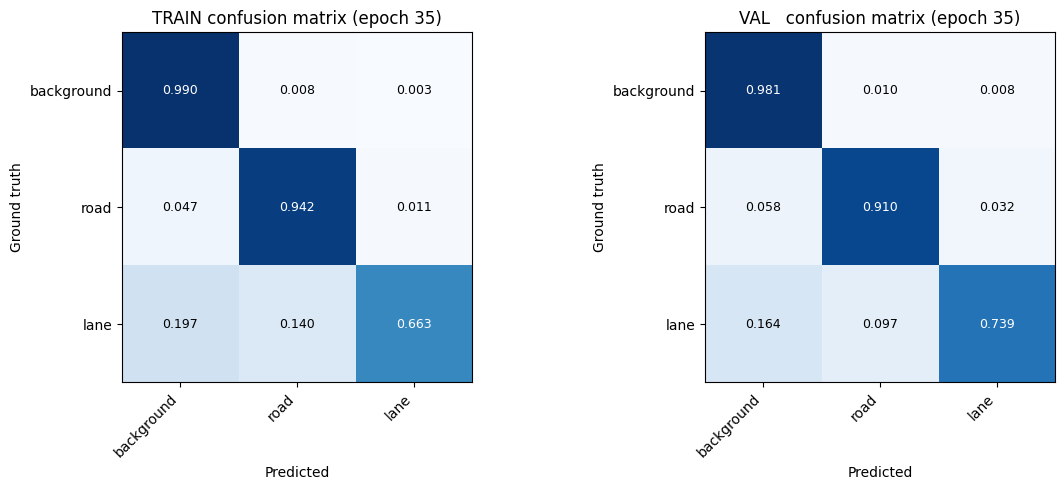

In [23]:
def normalize_cm(cm):
    cm = cm.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return cm / row_sums

def plot_cm(ax, cm, title):
    ncm = normalize_cm(cm)
    im = ax.imshow(ncm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground truth')
    for i in range(ncm.shape[0]):
        for j in range(ncm.shape[1]):
            ax.text(j, i, f'{ncm[i, j]:0.3f}', ha='center', va='center',
                    color='white' if ncm[i, j] > 0.5 else 'black', fontsize=9)
    ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_cm(axes[0], train_cms[-1], f'TRAIN confusion matrix (epoch {train_df["epoch"].iloc[-1]})')
plot_cm(axes[1], val_cms[-1],   f'VAL   confusion matrix (epoch {val_df["epoch"].iloc[-1]})')
plt.tight_layout(); plt.show()

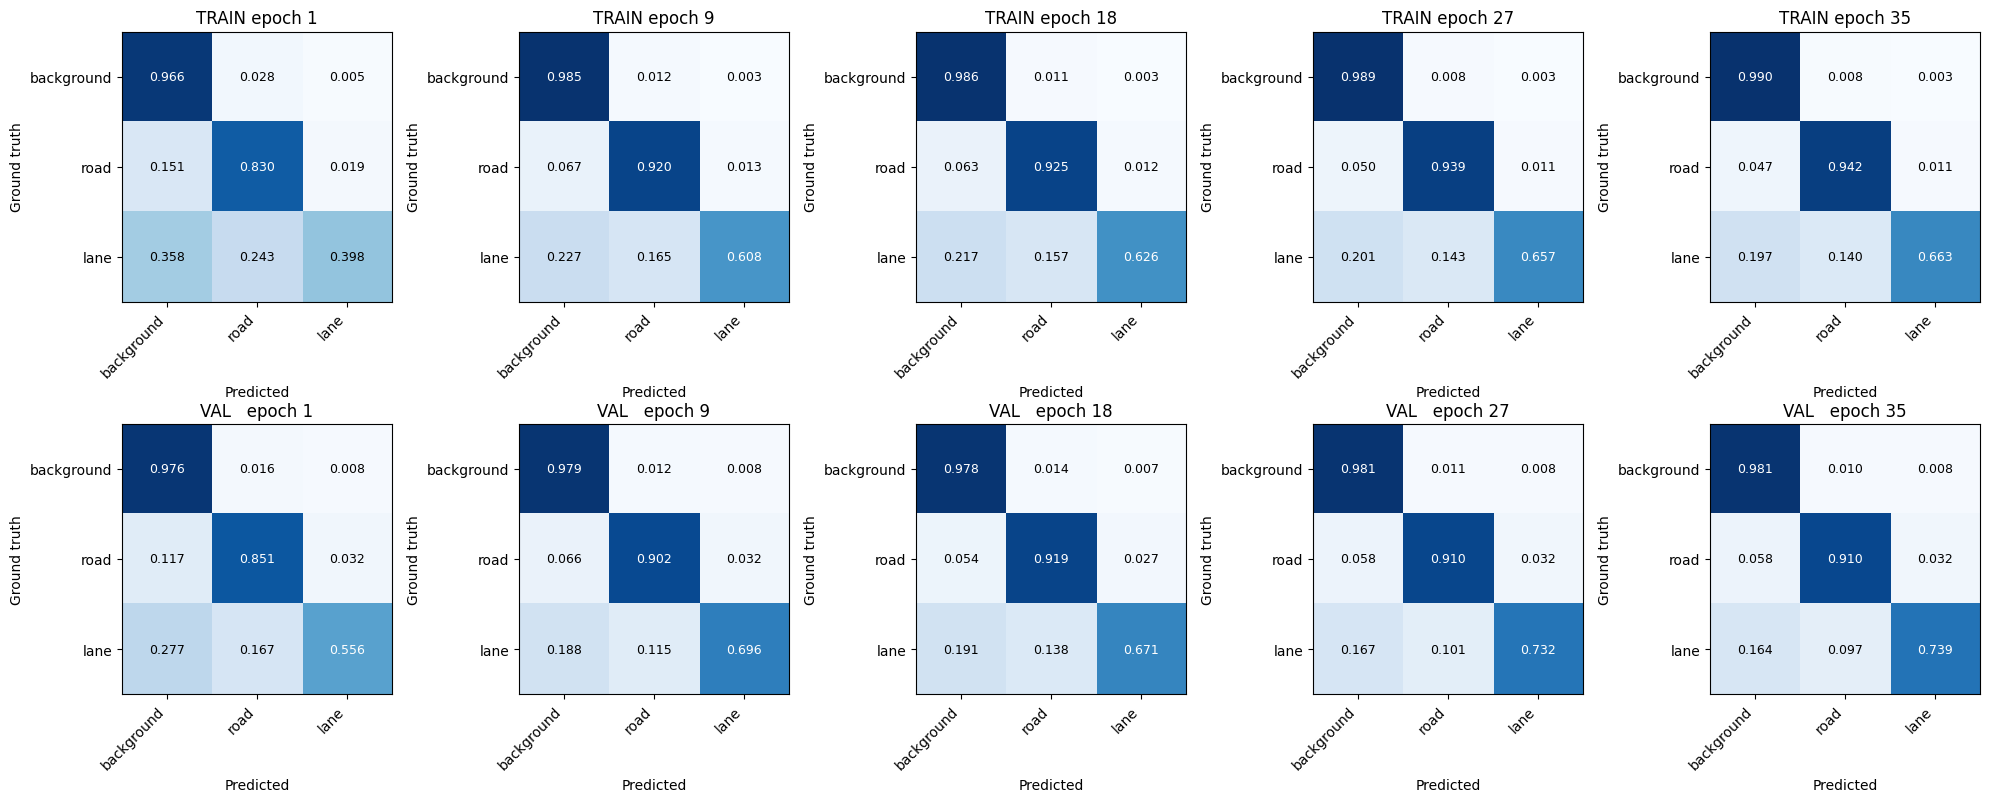

In [24]:
n_epochs = len(val_cms)
snap_epochs = sorted(set([0, n_epochs // 4, n_epochs // 2, (3 * n_epochs) // 4, n_epochs - 1]))

fig, axes = plt.subplots(2, len(snap_epochs), figsize=(4 * len(snap_epochs), 8))
for col, idx in enumerate(snap_epochs):
    plot_cm(axes[0, col], train_cms[idx], f'TRAIN epoch {train_df["epoch"].iloc[idx]}')
    plot_cm(axes[1, col], val_cms[idx],   f'VAL   epoch {val_df["epoch"].iloc[idx]}')
plt.tight_layout(); plt.show()

## 10. Per-epoch textual report

A compact, human-readable recap of what happened at every single epoch on both splits.

In [25]:
def epoch_report(train_row, val_row):
    ep = int(train_row['epoch'])
    lines = [f'Epoch {ep:>3d} | step {int(train_row["global_step"]):>6d} | '
             f'lr {train_row["lr_before_scheduler"]:.2e} -> {train_row["lr_after_scheduler"]:.2e}']
    lines.append(f'  TRAIN  loss={train_row["loss"]:.4f}  seg_loss={train_row["seg_loss"]:.4f}  '
                 f'mIoU={train_row["miou"]:.4f}  mAcc={train_row["macc"]:.4f}')
    lines.append(f'  VAL    loss={val_row["loss"]:.4f}  seg_loss={val_row["seg_loss"]:.4f}  '
                 f'mIoU={val_row["miou"]:.4f}  mAcc={val_row["macc"]:.4f}')
    lines.append(
        '  IoU    ' + '  '.join(
            f'{c}: train={train_row[f"iou_{c}"]:.4f} val={val_row[f"iou_{c}"]:.4f}' for c in CLASS_NAMES
        )
    )
    lines.append(
        '  Acc    ' + '  '.join(
            f'{c}: train={train_row[f"acc_{c}"]:.4f} val={val_row[f"acc_{c}"]:.4f}' for c in CLASS_NAMES
        )
    )
    lines.append(
        f'  Time   train={train_row["elapsed_seconds"]:.1f}s ({train_row["samples_per_second"]:.1f} samp/s)  '
        f'val={val_row["elapsed_seconds"]:.1f}s ({val_row["samples_per_second"]:.1f} samp/s)'
    )
    return '\n'.join(lines)

for (_, tr), (_, vr) in zip(train_df.iterrows(), val_df.iterrows()):
    print(epoch_report(tr, vr))
    print('-' * 110)

Epoch   1 | step   5834 | lr 1.00e-03 -> 1.00e-03
  TRAIN  loss=0.2336  seg_loss=0.2336  mIoU=0.6418  mAcc=0.7316
  VAL    loss=0.2487  seg_loss=0.2487  mIoU=0.6406  mAcc=0.7941
  IoU    background: train=0.9304 val=0.9510  road: train=0.7094 val=0.7829  lane: train=0.2855 val=0.1878
  Acc    background: train=0.9663 val=0.9757  road: train=0.8300 val=0.8508  lane: train=0.3985 val=0.5559
  Time   train=1610.9s (43.5 samp/s)  val=119.7s (83.5 samp/s)
--------------------------------------------------------------------------------------------------------------
Epoch   2 | step  11668 | lr 1.00e-03 -> 1.00e-03
  TRAIN  loss=0.1541  seg_loss=0.1541  mIoU=0.7217  mAcc=0.7968
  VAL    loss=0.2334  seg_loss=0.2334  mIoU=0.6550  mAcc=0.8144
  IoU    background: train=0.9552 val=0.9550  road: train=0.8019 val=0.8026  lane: train=0.4080 val=0.2073
  Acc    background: train=0.9795 val=0.9771  road: train=0.8893 val=0.8662  lane: train=0.5217 val=0.5999
  Time   train=1581.4s (44.3 samp/s)  val=

## 11. Headline takeaways

In [26]:
first_tr, last_tr = train_df.iloc[0], train_df.iloc[-1]
first_vl, last_vl = val_df.iloc[0],   val_df.iloc[-1]

best_val_miou_row = val_df.loc[val_df['miou'].idxmax()]
best_val_loss_row = val_df.loc[val_df['loss'].idxmin()]

print(f'Epochs analyzed:            {len(train_df)} (epoch {int(first_tr.epoch)} -> {int(last_tr.epoch)})')
print(f'TRAIN  loss:   {first_tr.loss:0.4f}  ->  {last_tr.loss:0.4f}   (delta {last_tr.loss - first_tr.loss:+0.4f})')
print(f'VAL    loss:   {first_vl.loss:0.4f}  ->  {last_vl.loss:0.4f}   (delta {last_vl.loss - first_vl.loss:+0.4f})')
print(f'TRAIN  mIoU:   {first_tr.miou:0.4f}  ->  {last_tr.miou:0.4f}   (delta {last_tr.miou - first_tr.miou:+0.4f})')
print(f'VAL    mIoU:   {first_vl.miou:0.4f}  ->  {last_vl.miou:0.4f}   (delta {last_vl.miou - first_vl.miou:+0.4f})')
print()
print(f'Best val mIoU: {best_val_miou_row.miou:0.4f} at epoch {int(best_val_miou_row.epoch)}')
print(f'Best val loss: {best_val_loss_row.loss:0.4f} at epoch {int(best_val_loss_row.epoch)}')
print()
final_gap = last_tr.miou - last_vl.miou
mean_gap  = (train_df['miou'] - val_df['miou']).mean()
print(f'Final train - val mIoU gap:     {final_gap:+0.4f}')
print(f'Average train - val mIoU gap:   {mean_gap:+0.4f}')
if final_gap > mean_gap + 0.02:
    print('  -> gap is widening toward the end: possible mild overfitting.')
elif abs(final_gap) < 0.02:
    print('  -> train and val are closely tracking each other.')
else:
    print('  -> train is consistently ahead of val, but gap is stable.')

Epochs analyzed:            35 (epoch 1 -> 35)
TRAIN  loss:   0.2336  ->  0.0876   (delta -0.1461)
VAL    loss:   0.2487  ->  0.1993   (delta -0.0494)
TRAIN  mIoU:   0.6418  ->  0.8060   (delta +0.1642)
VAL    mIoU:   0.6406  ->  0.6925   (delta +0.0519)

Best val mIoU: 0.6927 at epoch 31
Best val loss: 0.1991 at epoch 31

Final train - val mIoU gap:     +0.1135
Average train - val mIoU gap:   +0.0954
  -> train is consistently ahead of val, but gap is stable.


In [27]:
from IPython.display import display

def add_epoch_diagnostics(df, cms, split_name):
    out = df.copy()
    out['d_loss'] = out['loss'].diff()
    out['d_seg_loss'] = out['seg_loss'].diff()
    out['d_miou'] = out['miou'].diff()
    out['d_macc'] = out['macc'].diff()
    out['rolling_miou_3'] = out['miou'].rolling(3, min_periods=1).mean()
    out['rolling_loss_3'] = out['loss'].rolling(3, min_periods=1).mean()
    out['miou_rank'] = out['miou'].rank(ascending=False, method='dense').astype(int)
    out['loss_rank'] = out['loss'].rank(ascending=True, method='dense').astype(int)
    out['best_miou_so_far'] = out['miou'].cummax()
    out['best_loss_so_far'] = out['loss'].cummin()
    out['new_best_miou'] = out['miou'].cummax().diff().fillna(out['miou']).gt(0)
    out['new_best_loss'] = out['loss'].cummin().diff().fillna(-out['loss']).lt(0)
    out['miou_from_final_best'] = out['miou'].max() - out['miou']
    out['loss_from_final_best'] = out['loss'] - out['loss'].min()

    iou_cols = [f'iou_{c}' for c in CLASS_NAMES]
    acc_cols = [f'acc_{c}' for c in CLASS_NAMES]
    out['weakest_iou_class'] = out[iou_cols].idxmin(axis=1).str.replace('iou_', '', regex=False)
    out['weakest_acc_class'] = out[acc_cols].idxmin(axis=1).str.replace('acc_', '', regex=False)
    out['class_iou_span'] = out[iou_cols].max(axis=1) - out[iou_cols].min(axis=1)
    out['class_acc_span'] = out[acc_cols].max(axis=1) - out[acc_cols].min(axis=1)
    out['lane_vs_road_iou_gap'] = out['iou_road'] - out['iou_lane']
    out['lane_vs_background_iou_gap'] = out['iou_background'] - out['iou_lane']
    out['miou_gain_per_100s'] = 100.0 * out['d_miou'].fillna(0.0) / out['elapsed_seconds']

    def phase_label(delta):
        if pd.isna(delta):
            return 'baseline'
        if delta >= 0.010:
            return 'breakout'
        if delta >= 0.002:
            return 'gain'
        if delta <= -0.005:
            return 'regress'
        if delta < 0:
            return 'dip'
        return 'plateau'

    cm_rows = []
    for cm in cms:
        cm = cm.astype(np.float64)
        total = cm.sum()
        off = cm.copy()
        np.fill_diagonal(off, 0)
        total_errors = off.sum()
        if total_errors > 0:
            src_idx, dst_idx = np.unravel_index(np.argmax(off), off.shape)
            dominant_error = f'{CLASS_NAMES[src_idx]}->{CLASS_NAMES[dst_idx]}'
            dominant_error_share = off[src_idx, dst_idx] / total_errors
        else:
            dominant_error = 'none'
            dominant_error_share = 0.0

        gt_totals = cm.sum(axis=1)
        gt_error_rates = 1.0 - np.divide(np.diag(cm), gt_totals, out=np.zeros_like(gt_totals), where=gt_totals != 0)
        hardest_idx = int(gt_error_rates.argmax()) if len(gt_error_rates) else 0
        cm_rows.append({
            'error_rate': total_errors / total if total else 0.0,
            'dominant_error': dominant_error,
            'dominant_error_share': dominant_error_share,
            'hardest_gt_class': CLASS_NAMES[hardest_idx],
            'hardest_gt_error_rate': gt_error_rates[hardest_idx] if len(gt_error_rates) else 0.0,
        })

    out = pd.concat([out, pd.DataFrame(cm_rows)], axis=1)
    out['phase'] = out['d_miou'].apply(phase_label)
    out['split_name'] = split_name
    return out

train_diag = add_epoch_diagnostics(train_df, train_cms, 'train')
val_diag   = add_epoch_diagnostics(val_df,   val_cms,   'val')

comparison_df = train_diag[[
    'epoch', 'miou', 'loss', 'phase', 'dominant_error', 'class_iou_span', 'hardest_gt_error_rate'
]].merge(
    val_diag[[
        'epoch', 'miou', 'loss', 'phase', 'dominant_error', 'class_iou_span', 'hardest_gt_error_rate'
    ]],
    on='epoch', suffixes=('_train', '_val')
)
comparison_df['gap_miou'] = train_diag['miou'].values - val_diag['miou'].values
comparison_df['gap_loss'] = train_diag['loss'].values - val_diag['loss'].values
comparison_df['gap_class_iou_span'] = train_diag['class_iou_span'].values - val_diag['class_iou_span'].values

train_diag_cols = [
    'epoch', 'phase', 'miou', 'd_miou', 'loss', 'd_loss', 'rolling_miou_3',
    'weakest_iou_class', 'class_iou_span', 'lane_vs_road_iou_gap',
    'error_rate', 'dominant_error', 'dominant_error_share',
    'hardest_gt_class', 'hardest_gt_error_rate', 'miou_rank', 'loss_rank'
]
val_diag_cols = train_diag_cols.copy()
comparison_cols = [
    'epoch', 'gap_miou', 'gap_loss', 'phase_train', 'phase_val',
    'dominant_error_train', 'dominant_error_val', 'gap_class_iou_span'
]

print('=== TRAIN epoch diagnostics table ===')
display(train_diag[train_diag_cols])
print('=== VAL epoch diagnostics table ===')
display(val_diag[val_diag_cols])
print('=== Train vs Val diagnostic comparison ===')
display(comparison_df[comparison_cols])


def fmt_delta(value):
    return 'n/a' if pd.isna(value) else f'{value:+0.4f}'


def print_epoch_diagnostics(diag_df, split_name):
    print(f'=== {split_name.upper()} epoch diagnostics ===')
    for _, row in diag_df.iterrows():
        tags = []
        if row['new_best_miou']:
            tags.append('new best mIoU')
        if row['new_best_loss']:
            tags.append('new best loss')
        if not pd.isna(row['d_miou']):
            if row['d_miou'] >= 0.010:
                tags.append('sharp gain')
            elif row['d_miou'] >= 0.002:
                tags.append('steady gain')
            elif row['d_miou'] <= -0.005:
                tags.append('clear regression')
            elif row['d_miou'] < 0:
                tags.append('minor dip')
            else:
                tags.append('flat')
        tags.append(f'weakest IoU={row["weakest_iou_class"]}')
        tags.append(f'dominant error={row["dominant_error"]}')
        print(
            f'Epoch {int(row.epoch):>2d} | {row.phase:<8} | '
            f'mIoU={row.miou:0.4f} ({fmt_delta(row.d_miou)}) | '
            f'loss={row.loss:0.4f} ({fmt_delta(row.d_loss)}) | '
            f'class span={row.class_iou_span:0.4f} | '
            f'error rate={row.error_rate:0.2%} | '
            f'hardest GT={row.hardest_gt_class} ({row.hardest_gt_error_rate:0.2%}) | '
            + ', '.join(tags)
        )


print_epoch_diagnostics(train_diag, 'train')
print()
print_epoch_diagnostics(val_diag, 'val')


=== TRAIN epoch diagnostics table ===


,epoch,phase,miou,d_miou,loss,d_loss,rolling_miou_3,weakest_iou_class,class_iou_span,lane_vs_road_iou_gap,error_rate,dominant_error,dominant_error_share,hardest_gt_class,hardest_gt_error_rate,miou_rank,loss_rank
0,1,baseline,0.641787,NaN,0.233620,NaN,0.641787,lane,0.644888,0.423872,0.066810,road->background,0.369438,lane,0.601503,35,35
1,2,breakout,0.721690,0.079903,0.154141,-0.079479,0.681739,lane,0.547196,0.393879,0.043933,road->background,0.353686,lane,0.478346,34,34
2,3,breakout,0.740682,0.018991,0.137648,-0.016493,0.701386,lane,0.519703,0.381671,0.039441,road->background,0.346641,lane,0.444435,33,33
3,4,breakout,0.751072,0.010390,0.129034,-0.008614,0.737815,lane,0.504094,0.374221,0.037085,road->background,0.342027,lane,0.425740,32,32
4,5,gain,0.757236,0.006164,0.124021,-0.005012,0.749663,lane,0.494982,0.370054,0.035677,road->background,0.340758,lane,0.414991,31,31
5,6,gain,0.762126,0.004890,0.120087,-0.003934,0.756812,lane,0.487726,0.366680,0.034566,road->background,0.340203,lane,0.406482,30,30
6,7,gain,0.765558,0.003432,0.117294,-0.002793,0.761640,lane,0.482766,0.364513,0.033770,road->background,0.340212,lane,0.400658,29,29
7,8,gain,0.768378,0.002820,0.115041,-0.002254,0.765354,lane,0.478348,0.362238,0.033170,road->background,0.339137,lane,0.395355,28,28
8,9,gain,0.770902,0.002524,0.113101,-0.001940,0.768279,lane,0.474958,0.361093,0.032560,road->background,0.338441,lane,0.391547,27,27
9,10,plateau,0.772694,0.001792,0.111836,-0.001265,0.770658,lane,0.471844,0.359145,0.032210,road->background,0.338158,lane,0.387960,26,26


=== VAL epoch diagnostics table ===


,epoch,phase,miou,d_miou,loss,d_loss,rolling_miou_3,weakest_iou_class,class_iou_span,lane_vs_road_iou_gap,error_rate,dominant_error,dominant_error_share,hardest_gt_class,hardest_gt_error_rate,miou_rank,loss_rank
0,1,baseline,0.640553,NaN,0.248693,NaN,0.640553,lane,0.763194,0.595124,0.047925,road->background,0.411943,lane,0.444129,35,35
1,2,breakout,0.654952,0.014399,0.233400,-0.015293,0.647752,lane,0.747692,0.595286,0.043913,road->background,0.400305,lane,0.400077,34,34
2,3,breakout,0.670822,0.015870,0.219303,-0.014097,0.655442,lane,0.742555,0.613369,0.038150,background->road,0.369204,lane,0.391658,31,32
3,4,regress,0.663333,-0.007489,0.224607,0.005303,0.663036,lane,0.744632,0.601837,0.041101,road->background,0.422061,lane,0.322168,33,33
4,5,gain,0.670737,0.007404,0.218909,-0.005697,0.668297,lane,0.738668,0.605510,0.038647,road->background,0.336008,lane,0.352988,32,31
5,6,gain,0.677267,0.006530,0.212979,-0.005930,0.670446,lane,0.736134,0.613189,0.036610,road->background,0.317573,lane,0.318817,27,28
6,7,plateau,0.677431,0.000164,0.213508,0.000528,0.675145,lane,0.735883,0.613671,0.036655,road->background,0.328452,lane,0.312941,26,29
7,8,dip,0.677120,-0.000310,0.215570,0.002063,0.677273,lane,0.742734,0.622027,0.036181,background->road,0.309747,lane,0.296518,28,30
8,9,gain,0.680595,0.003475,0.210997,-0.004573,0.678382,lane,0.734387,0.616303,0.035575,road->background,0.314135,lane,0.303927,24,26
9,10,dip,0.679255,-0.001340,0.210674,-0.000324,0.678990,lane,0.735308,0.613606,0.035728,road->background,0.360462,lane,0.305411,25,23


=== Train vs Val diagnostic comparison ===


,epoch,gap_miou,gap_loss,phase_train,phase_val,dominant_error_train,dominant_error_val,gap_class_iou_span
0,1,0.001234,-0.015073,baseline,baseline,road->background,road->background,-0.118306
1,2,0.066739,-0.079260,breakout,breakout,road->background,road->background,-0.200496
2,3,0.069860,-0.081655,breakout,breakout,road->background,background->road,-0.222852
3,4,0.087739,-0.095573,breakout,regress,road->background,road->background,-0.240537
4,5,0.086499,-0.094888,gain,gain,road->background,road->background,-0.243686
5,6,0.084859,-0.092892,gain,gain,road->background,road->background,-0.248408
6,7,0.088127,-0.096213,gain,plateau,road->background,road->background,-0.253117
7,8,0.091257,-0.100530,gain,dip,road->background,background->road,-0.264386
8,9,0.090307,-0.097897,gain,gain,road->background,road->background,-0.259429
9,10,0.093439,-0.098837,plateau,dip,road->background,road->background,-0.263464


=== TRAIN epoch diagnostics ===
Epoch  1 | baseline | mIoU=0.6418 (n/a) | loss=0.2336 (n/a) | class span=0.6449 | error rate=6.68% | hardest GT=lane (60.15%) | new best mIoU, new best loss, weakest IoU=lane, dominant error=road->background
Epoch  2 | breakout | mIoU=0.7217 (+0.0799) | loss=0.1541 (-0.0795) | class span=0.5472 | error rate=4.39% | hardest GT=lane (47.83%) | new best mIoU, new best loss, sharp gain, weakest IoU=lane, dominant error=road->background
Epoch  3 | breakout | mIoU=0.7407 (+0.0190) | loss=0.1376 (-0.0165) | class span=0.5197 | error rate=3.94% | hardest GT=lane (44.44%) | new best mIoU, new best loss, sharp gain, weakest IoU=lane, dominant error=road->background
Epoch  4 | breakout | mIoU=0.7511 (+0.0104) | loss=0.1290 (-0.0086) | class span=0.5041 | error rate=3.71% | hardest GT=lane (42.57%) | new best mIoU, new best loss, sharp gain, weakest IoU=lane, dominant error=road->background
Epoch  5 | gain     | mIoU=0.7572 (+0.0062) | loss=0.1240 (-0.0050) | class 

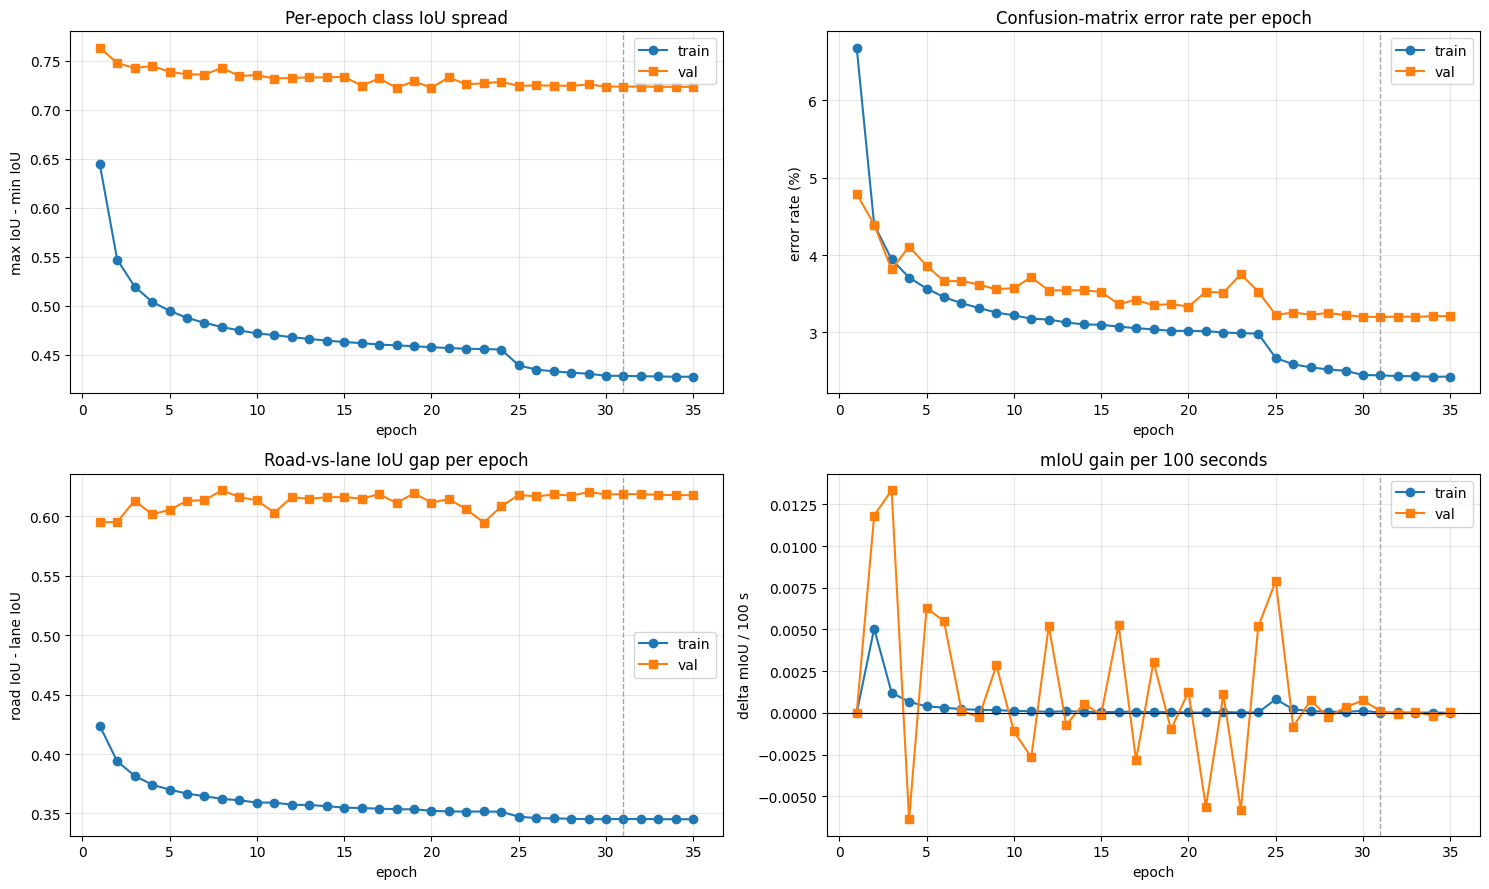

Best validation mIoU epoch used as reference line: 31
Interpretation: class spread should compress, error rate should fall, and lane-vs-road gap should narrow.


In [28]:
best_val_epoch = int(val_diag.loc[val_diag['miou'].idxmax(), 'epoch'])

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(train_diag['epoch'], train_diag['class_iou_span'], marker='o', label='train')
axes[0, 0].plot(val_diag['epoch'],   val_diag['class_iou_span'],   marker='s', label='val')
axes[0, 0].set_title('Per-epoch class IoU spread')
axes[0, 0].set_xlabel('epoch'); axes[0, 0].set_ylabel('max IoU - min IoU')
axes[0, 0].grid(True, alpha=0.3); axes[0, 0].legend()

axes[0, 1].plot(train_diag['epoch'], 100 * train_diag['error_rate'], marker='o', label='train')
axes[0, 1].plot(val_diag['epoch'],   100 * val_diag['error_rate'],   marker='s', label='val')
axes[0, 1].set_title('Confusion-matrix error rate per epoch')
axes[0, 1].set_xlabel('epoch'); axes[0, 1].set_ylabel('error rate (%)')
axes[0, 1].grid(True, alpha=0.3); axes[0, 1].legend()

axes[1, 0].plot(train_diag['epoch'], train_diag['lane_vs_road_iou_gap'], marker='o', label='train')
axes[1, 0].plot(val_diag['epoch'],   val_diag['lane_vs_road_iou_gap'],   marker='s', label='val')
axes[1, 0].set_title('Road-vs-lane IoU gap per epoch')
axes[1, 0].set_xlabel('epoch'); axes[1, 0].set_ylabel('road IoU - lane IoU')
axes[1, 0].grid(True, alpha=0.3); axes[1, 0].legend()

axes[1, 1].plot(train_diag['epoch'], train_diag['miou_gain_per_100s'], marker='o', label='train')
axes[1, 1].plot(val_diag['epoch'],   val_diag['miou_gain_per_100s'],   marker='s', label='val')
axes[1, 1].axhline(0, color='k', linewidth=0.8)
axes[1, 1].set_title('mIoU gain per 100 seconds')
axes[1, 1].set_xlabel('epoch'); axes[1, 1].set_ylabel('delta mIoU / 100 s')
axes[1, 1].grid(True, alpha=0.3); axes[1, 1].legend()

for ax in axes.ravel():
    ax.axvline(best_val_epoch, color='0.5', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout(); plt.show()

print(f'Best validation mIoU epoch used as reference line: {best_val_epoch}')
print('Interpretation: class spread should compress, error rate should fall, and lane-vs-road gap should narrow.')


In [29]:
from PIL import Image

image = Image.open("/home/aman/Projects/Auto/HybridNets/data/smoke_subset/images/val/b1c66a42-6f7d68ca.jpg")

image.size

(1280, 720)